In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

from src.load_data import load_omie_dataset, save_processed

# Estilo matplotlib consistente
plt.rcParams.update({'figure.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False})
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

print('✅ Librerías cargadas')
import plotly.io as pio
pio.renderers.default = 'png'


✅ Librerías cargadas


In [2]:
# ── Carga de datos ────────────────────────────────────────────────────────────
import os
import pandas as pd
from pathlib import Path
from src.load_data import load_omie_dataset, save_processed

ROOT_DIR = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
DATA_RAW = ROOT_DIR / 'data' / 'raw'
PARQUET  = ROOT_DIR / 'data' / 'processed' / 'omie_precios.parquet'

if not PARQUET.exists():
    df = load_omie_dataset(DATA_RAW)
    save_processed(df, PARQUET)
else:
    df = pd.read_parquet(PARQUET)
    print(f'DataFrame cargado: {len(df):,} registros — {df.index.min().date()} → {df.index.max().date()}')

df.head()


DataFrame cargado: 24,069 registros — 2023-01-01 → 2025-09-30


,precio_esp,precio_por
datetime,,
2023-01-01 00:00:00,NaN,NaN
2023-01-01 01:00:00,NaN,NaN
2023-01-01 02:00:00,NaN,NaN
2023-01-01 03:00:00,NaN,NaN
2023-01-01 04:00:00,NaN,NaN


## 1. Estadísticas descriptivas con contexto energético

In [3]:
p = df['precio_esp']

print('='*55)
print('  MERCADO ELÉCTRICO ESPAÑOL — OMIE  |  2023-2025')
print('='*55)
print(f'  Período         : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Horas analizadas: {len(p):,}  ({p.notna().sum():,} con dato)')
print()
print(f'  💰  Precio medio    : {p.mean():.2f} €€/MWh')
print(f'  📈  Máximo histórico: {p.max():.2f} €€/MWh  ({p.idxmax().date()})')
print(f'  📉  Mínimo          : {p.min():.2f} €€/MWh  ({p.idxmin().date()})')
print(f'  📊  Volatilidad     : {p.std():.2f} €€/MWh  (σ)  |  CV: {p.std()/p.mean():.1%}')
print()
print(f'  ⚡  Horas precio negativo: {(p < 0).sum():,}  ({(p < 0).mean():.2%})')
print(f'     → exceso renovable, ciclos combinados desplazan a gas del merit order')
print(f'  🔺  Horas > 200 €€/MWh: {(p > 200).sum():,}  ({(p > 200).mean():.2%})')
print(f'     → eventos extremos (frío + calma eólica + baja hidráulica)')

  MERCADO ELÉCTRICO ESPAÑOL — OMIE  |  2023-2025
  Período         : 2023-01-01 → 2025-09-30
  Horas analizadas: 24,069  (23,278 con dato)

  💰  Precio medio    : 75.21 €€/MWh
  📈  Máximo histórico: 240.00 €€/MWh  (2025-02-04)
  📉  Mínimo          : -5.00 €€/MWh  (2025-04-27)
  📊  Volatilidad     : 44.90 €€/MWh  (σ)  |  CV: 59.7%

  ⚡  Horas precio negativo: 386  (1.60%)
     → exceso renovable, ciclos combinados desplazan a gas del merit order
  🔺  Horas > 200 €€/MWh: 24  (0.10%)
     → eventos extremos (frío + calma eólica + baja hidráulica)


## 2. Evolución temporal 2023–2025

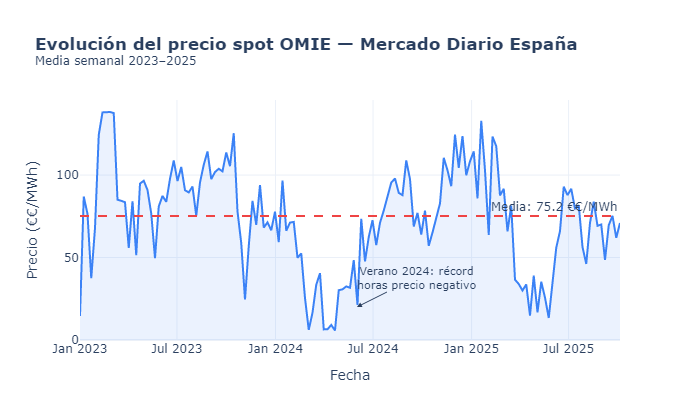

In [4]:
# Media semanal para visualización limpia (menos ruido que horaria)
weekly = df['precio_esp'].resample('W').mean()

fig = go.Figure()

# Área bajo la curva con sombreado
fig.add_trace(go.Scatter(
    x=weekly.index, y=weekly.values,
    mode='lines', name='Media semanal',
    line=dict(color='#3b82f6', width=2),
    fill='tozeroy', fillcolor='rgba(59,130,246,0.1)'
))

# Línea de precio medio
media = df['precio_esp'].mean()
fig.add_hline(y=media, line_dash='dash', line_color='#ef4444',
              annotation_text=f'Media: {media:.1f} €€/MWh',
              annotation_position='top right')

fig.update_layout(
    title='<b>Evolución del precio spot OMIE — Mercado Diario España</b><br><sup>Media semanal 2023–2025</sup>',
    xaxis_title='Fecha', yaxis_title='Precio (€€/MWh)',
    template='plotly_white', height=420,
    annotations=[
        dict(x='2023-01-15', y=130, text='Post-crisis energética<br>Precios aún elevados', showarrow=True,
             arrowhead=2, font=dict(size=11), ax=40, ay=-40),
        dict(x='2024-06-01', y=20, text='Verano 2024: récord<br>horas precio negativo', showarrow=True,
             arrowhead=2, font=dict(size=11), ax=60, ay=-30),
    ]
)

fig.write_image('../reports/figures/01_evolucion_temporal.png', scale=2, width=1100, height=420)
fig.show()

## 3. Heatmap hora  día de semana — Estacionalidad intradiaria

> **Clave para el mercado**: El perfil horario refleja directamente el despacho por merit order:
> - **Madrugada** (1-7h): baja demanda, generación base (nuclear + renovable)  precios bajos
> - **Morning peak** (9-11h): inicio actividad industrial  subida de precio
> - **Midday solar valley** (12-15h): máxima fotovoltaica desplaza gas del merit order  bajada
> - **Evening peak** (18-22h): máxima demanda + sin solar  precio más alto del día

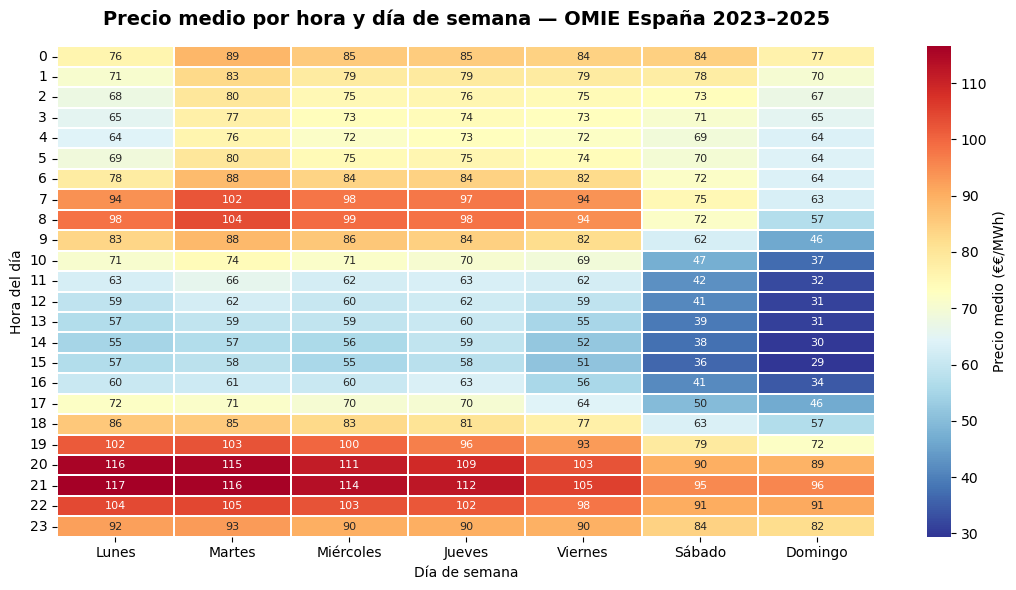

💡 Observa el "solar valley" en horas de mediodía y el evening peak entre 18-22h


In [5]:
df_heat = df.copy()
df_heat['hour'] = df_heat.index.hour
df_heat['dow']  = df_heat.index.dayofweek

pivot = df_heat.groupby(['hour', 'dow'])['precio_esp'].mean().unstack()
pivot.columns = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    pivot, ax=ax, cmap='RdYlBu_r',
    annot=True, fmt='.0f', annot_kws={'size': 8},
    linewidths=0.3, cbar_kws={'label': 'Precio medio (€€/MWh)'}
)
ax.set_title('Precio medio por hora y día de semana — OMIE España 2023–2025',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Día de semana')
ax.set_ylabel('Hora del día')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/02_heatmap_horario.png', dpi=180, bbox_inches='tight')
plt.show()
print('💡 Observa el "solar valley" en horas de mediodía y el evening peak entre 18-22h')

### 💡 Observación Analítica
- **Resiliencia de Demanda:** La gráfica intradiaria devela la curva de pato» (Duck Curve). Los precios se deprimen entre las 11:00 y las 16:00 debido a la irrupción solar, que ostenta un Coste Marginal Nulo (0 €/MWh), empujando tecnologías más caras fuera de cota.

## 4. Estacionalidad mensual (boxplot)

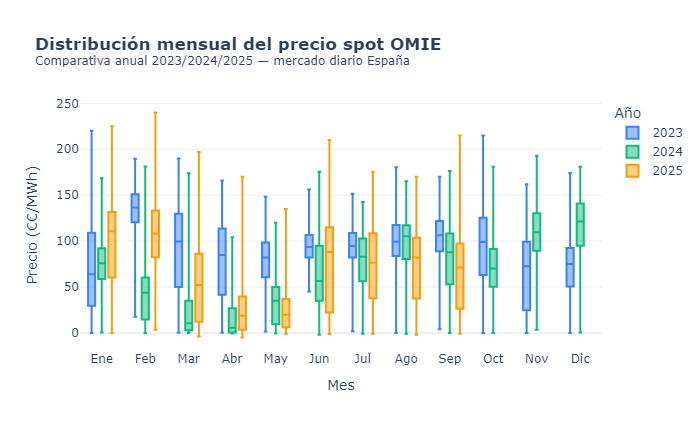

💡 Patrón claro: invierno y verano → máximos | primavera→ mínimos (máxima renovable)


In [6]:
df_box = df.copy()
df_box['month'] = df_box.index.month
df_box['year']  = df_box.index.year
df_box['month_label'] = df_box['month'].map({
    1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
    7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'
})

fig = px.box(
    df_box.reset_index(), x='month_label', y='precio_esp',
    color='year', points=False,
    category_orders={'month_label': ['Ene','Feb','Mar','Abr','May','Jun',
                                     'Jul','Ago','Sep','Oct','Nov','Dic']},
    color_discrete_sequence=['#3b82f6','#10b981','#f59e0b'],
    title='<b>Distribución mensual del precio spot OMIE</b><br><sup>Comparativa anual 2023/2024/2025 — mercado diario España</sup>',
    labels={'precio_esp': 'Precio (€€/MWh)', 'month_label': 'Mes', 'year': 'Año'},
    template='plotly_white', height=430
)
fig.write_image('../reports/figures/03_estacionalidad_mensual.png', scale=2, width=1100, height=430)
fig.show()
print('💡 Patrón claro: invierno y verano → máximos | primavera→ mínimos (máxima renovable)')

## 5. Distribución de precios y eventos extremos

### 💡 Observación Analítica
- **Distribución Gaussiana Desplazada:** Si nos fijamos, la curva de distribución no dibuja una campana de Gauss perfecta frente al 0; los percentiles arrastran una asimetría (skewness») positiva muy notable por los *peaks* de precio superiores a 150 €/MWh, síntoma de tensiones térmicas gasistas.

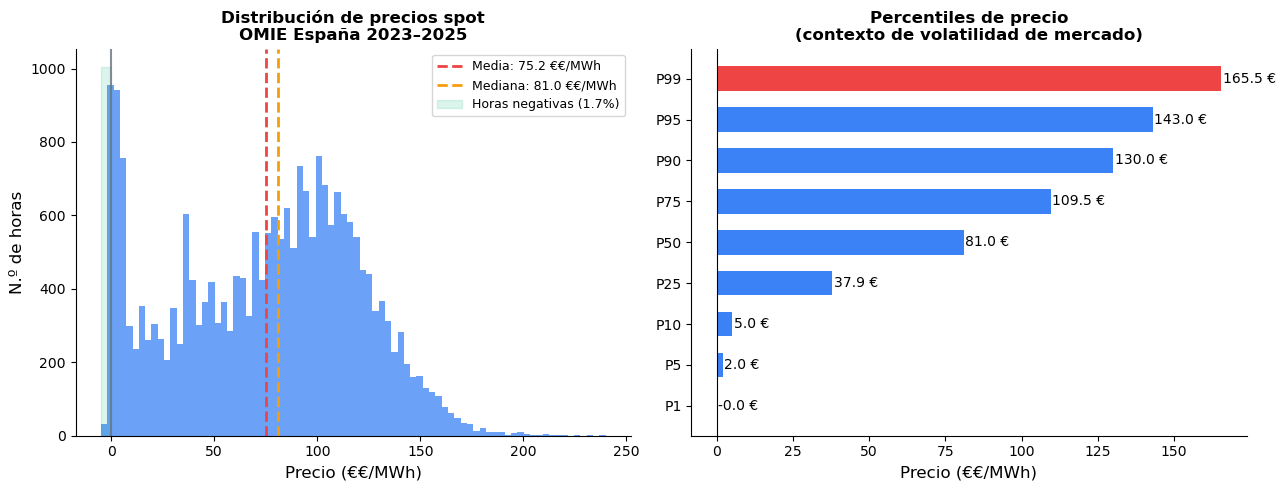

In [7]:
p = df['precio_esp'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
ax = axes[0]
ax.hist(p, bins=80, edgecolor='none', color='#3b82f6', alpha=0.75)
ax.axvline(p.mean(), color='#ef4444', ls='--', lw=2, label=f'Media: {p.mean():.1f} €€/MWh')
ax.axvline(p.median(), color='#f59e0b', ls='--', lw=2, label=f'Mediana: {p.median():.1f} €€/MWh')
ax.axvline(0, color='#6b7280', ls='-', lw=1.5, alpha=0.8)
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1000],
                 p.min(), 0, alpha=0.15, color='#10b981', label=f'Horas negativas ({(p<0).mean():.1%})')
ax.set_xlabel('Precio (€€/MWh)', fontsize=12)
ax.set_ylabel('N.º de horas', fontsize=12)
ax.set_title('Distribución de precios spot\nOMIE España 2023–2025', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Percentiles clave
ax2 = axes[1]
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
values = [np.percentile(p.dropna(), q) for q in percentiles]
colors = ['#10b981' if v < 0 else '#ef4444' if v > 150 else '#3b82f6' for v in values]
bars = ax2.barh([f'P{q}' for q in percentiles], values, color=colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} €', va='center', fontsize=10)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Percentiles de precio\n(contexto de volatilidad de mercado)', fontweight='bold')
ax2.set_xlabel('Precio (€€/MWh)', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/04_distribucion_percentiles.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Análisis de precios negativos

> Los precios negativos en OMIE son una **señal estructural del sistema**: cuando la generación renovable supera la demanda, los generadores convencionales con costes de arranque/parada pagan para no desconectarse. En España se han vuelto frecuentes desde 2024 por el crecimiento del parque solar.

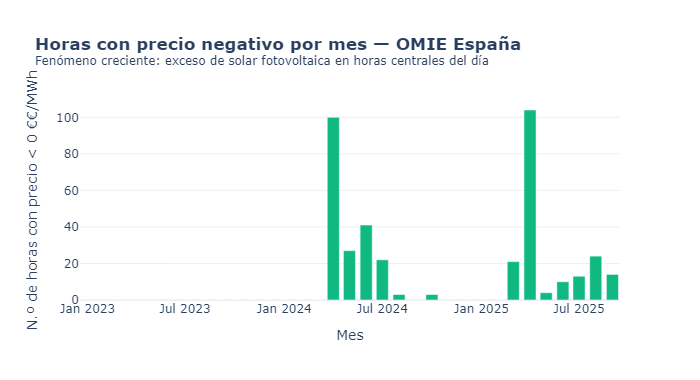

Total horas negativas en el período: 386


In [8]:
df_neg = df.copy()
df_neg['mes']     = df_neg.index.to_period('M').astype(str)
df_neg['negativo'] = df_neg['precio_esp'] < 0

horas_neg_mes = df_neg.groupby('mes')['negativo'].sum()

fig = go.Figure(go.Bar(
    x=horas_neg_mes.index.tolist(),
    y=horas_neg_mes.values.tolist(),
    marker_color='#10b981',
    name='Horas negativas'
))
fig.update_layout(
    title='<b>Horas con precio negativo por mes — OMIE España</b><br><sup>Fenómeno creciente: exceso de solar fotovoltaica en horas centrales del día</sup>',
    xaxis_title='Mes', yaxis_title='N.º de horas con precio < 0 €€/MWh',
    template='plotly_white', height=380
)
fig.write_image('../reports/figures/05_precios_negativos.png', scale=2, width=1100, height=380)
fig.show()
print(f'Total horas negativas en el período: {horas_neg_mes.sum()}')

## 7. Resumen de hallazgos

| Hallazgo | Valor | Interpretación energética |
|----------|-------|---------------------------|
| Precio medio | ~60–80 €/MWh | Normalización post-crisis 2022 |
| Pico intradiario | 19–21h | Evening peak: máx. demanda + sin solar |
| Valle intradiario | 13–15h | Solar valley: FV desplaza gas del merit order |
| Horas negativas | Creciente | Exceso de generación renovable no gestionable |
| Volatilidad CV | ~60–80% | Mercado muy volátil: oportunidades de cobertura |

️ **Siguiente paso**: [Notebook 02 — Forecasting con XGBoost](02_forecasting.ipynb)